# Batch Audio Embedding Extraction

This notebook demonstrates how to extract neural embeddings from audio files using two avex bioacoustics models:

| Model | Architecture | Feature output | Pooled dim |
|---|---|---|---|
| `esp_aves2_sl_beats_all` | BEATs Transformer | `(1, T, 768)` | 768 |
| `esp_aves2_effnetb0_all` | EfficientNet-B0 CNN | `(1, C, H, W)` | C (≈ 1280) |

We demonstrate the full workflow:
1. Shard audio into overlapping windows
2. Extract per-window embeddings with both models
3. Pool and aggregate embeddings
4. Visualise the embedding space with interactive UMAP scatter plots

**Self-contained demo**: We generate synthetic audio clips so no download is needed. Point `AUDIO_DIR` at any real audio directory to use your own data.

## 1 — Setup

In [1]:
from __future__ import annotations

import warnings

warnings.filterwarnings("ignore")

import pathlib
import sys

import numpy as np
import plotly.express as px
import plotly.graph_objects as go
import soundfile as sf
import torch
from plotly.subplots import make_subplots

sys.path.insert(0, str(pathlib.Path().resolve().parents[1]))
from avex import load_model
from IPython.display import display

from utils.visualization import plot_umap, plot_umap_static

NOTEBOOK_DIR = pathlib.Path().resolve()
AUDIO_DIR = NOTEBOOK_DIR / "demo_audio"
EMBED_DIR = NOTEBOOK_DIR / "demo_embeddings"
for d in [AUDIO_DIR, EMBED_DIR]:
    d.mkdir(parents=True, exist_ok=True)
SAMPLE_RATE = 16_000
WINDOW_SECONDS = 1.0
HOP_SECONDS = 0.5
BEATS_MODEL = "esp_aves2_sl_beats_all"
EFFNET_MODEL = "esp_aves2_effnetb0_all"
DEVICE = "cpu"
print(f"Audio dir : {AUDIO_DIR}")
print(f"Embed dir : {EMBED_DIR}")

2026-04-20 16:24:42.415584: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


2026-04-20 16:24:44.757638: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


Audio dir : /home/marius_miron_earthspecies_org/code/avex-examples/examples/02_embed_audio/demo_audio
Embed dir : /home/marius_miron_earthspecies_org/code/avex-examples/examples/02_embed_audio/demo_embeddings


## 2 — Generate synthetic audio clips

In a real workflow you would set `AUDIO_DIR` to a folder containing WAV or FLAC recordings. Here we synthesise 12 short clips: 4 frequency profiles × 3 clips each, mimicking different "call types".

Each clip is 3 seconds of a pure sinusoidal tone at a dominant frequency with added white Gaussian noise (SNR = 15 dB). The four frequency profiles are:

| Category | Frequency |
|---|---|
| `low` | 220 Hz |
| `mid_low` | 440 Hz |
| `mid_high` | 880 Hz |
| `high` | 1760 Hz |

These represent stylised bioacoustics call classes with distinct spectral signatures — ideal for verifying that our embeddings capture frequency-level structure.

In [2]:
def generate_tone(freq_hz: float, duration_s: float, sr: int, snr_db: float = 15.0) -> np.ndarray:
    """Synthesise a mono sinusoidal tone with additive white Gaussian noise.

    Parameters
    ----------
    freq_hz : float
        Fundamental frequency in Hz.
    duration_s : float
        Clip duration in seconds.
    sr : int
        Sample rate in Hz.
    snr_db : float
        Signal-to-noise ratio in dB.

    Returns
    -------
    np.ndarray
        Float32 array of shape ``(sr * duration_s,)``.
    """
    t = np.linspace(0, duration_s, int(sr * duration_s), endpoint=False)
    tone = np.sin(2 * np.pi * freq_hz * t).astype(np.float32)
    noise_power = 10 ** (-snr_db / 10)
    noise = np.random.default_rng(42).normal(0, np.sqrt(noise_power), len(t)).astype(np.float32)
    return tone + noise


CATEGORIES = {"low": 220, "mid_low": 440, "mid_high": 880, "high": 1760}
CLIPS_PER_CATEGORY = 3
all_paths: list[pathlib.Path] = []
all_labels: list[str] = []

for cat, freq in CATEGORIES.items():
    for i in range(CLIPS_PER_CATEGORY):
        audio = generate_tone(freq, duration_s=3.0, sr=SAMPLE_RATE)
        path = AUDIO_DIR / f"{cat}_{i:02d}.wav"
        sf.write(str(path), audio, SAMPLE_RATE)
        all_paths.append(path)
        all_labels.append(cat)

print(f"Generated {len(all_paths)} clips: {list(CATEGORIES.keys())}")

Generated 12 clips: ['low', 'mid_low', 'mid_high', 'high']


## 3 — Visualise the synthetic audio

Before extracting embeddings, let's look at the waveforms. We plot the first 250 ms of each frequency profile to verify the four distinct sinusoidal patterns. Notice how the oscillation frequency doubles with each category — corresponding to one octave steps.

In [3]:
fig = make_subplots(rows=2, cols=2, subplot_titles=list(CATEGORIES.keys()))

for idx, (cat, freq) in enumerate(CATEGORIES.items()):
    audio = generate_tone(freq, duration_s=3.0, sr=SAMPLE_RATE)
    t = np.linspace(0, 3.0, len(audio))
    n_show = SAMPLE_RATE // 4  # show 250 ms
    row, col = divmod(idx, 2)
    fig.add_trace(
        go.Scatter(x=t[:n_show], y=audio[:n_show], mode="lines", line=dict(width=0.8), name=cat, showlegend=True),
        row=row + 1,
        col=col + 1,
    )

fig.update_layout(
    title="Synthetic waveforms (first 250 ms) — 4 frequency profiles",
    height=500,
)
fig.show()

## 4 — Audio windowing (sharding)

Most neural audio models expect a fixed-length input. For variable-length recordings, we **shard** (split) the audio into overlapping windows:

```
Audio:    |=========================================|
Window 0: |======|
Window 1:    |======|
Window 2:       |======|
Window 3:          |======|
Window 4:             |======|
Window 5:                |======|  (zero-padded if needed)
```

Key parameters:
- **`window_seconds`** (`1.0 s`): length of each input window fed to the model
- **`hop_seconds`** (`0.5 s`): stride between consecutive window starts — `hop < window` gives overlap

With `window=1.0 s` and `hop=0.5 s`, consecutive windows share 50% of their content. This overlap ensures that acoustic events near window boundaries are captured in at least one window without edge effects.

The final window is **zero-padded** if the remaining audio is shorter than `window_seconds`.

In [4]:
def shard_audio(audio: np.ndarray, sr: int, window_s: float, hop_s: float) -> list[np.ndarray]:
    """Split an audio array into fixed-length overlapping windows.

    Trailing incomplete windows are zero-padded to ``window_s`` seconds.

    Parameters
    ----------
    audio : np.ndarray
        Mono float32 audio array.
    sr : int
        Sample rate in Hz.
    window_s : float
        Window length in seconds.
    hop_s : float
        Hop between consecutive windows in seconds.

    Returns
    -------
    list[np.ndarray]
        List of zero-padded windows, each of length ``int(window_s * sr)``.
    """
    win_len = int(window_s * sr)
    hop_len = int(hop_s * sr)
    windows, start = [], 0
    while start < len(audio):
        chunk = audio[start : start + win_len]
        if len(chunk) < win_len:
            chunk = np.pad(chunk, (0, win_len - len(chunk)))
        windows.append(chunk)
        start += hop_len
    return windows


# Demo: shard a 3-second clip
demo_audio = generate_tone(440, duration_s=3.0, sr=SAMPLE_RATE)
demo_windows = shard_audio(demo_audio, SAMPLE_RATE, WINDOW_SECONDS, HOP_SECONDS)
print(f"Audio duration : 3.0 s  ({len(demo_audio)} samples)")
print(f"Window length  : {WINDOW_SECONDS} s  ({int(WINDOW_SECONDS * SAMPLE_RATE)} samples)")
print(f"Hop size       : {HOP_SECONDS} s  ({int(HOP_SECONDS * SAMPLE_RATE)} samples)")
print(f"Number of windows: {len(demo_windows)}")

Audio duration : 3.0 s  (48000 samples)
Window length  : 1.0 s  (16000 samples)
Hop size       : 0.5 s  (8000 samples)
Number of windows: 6


In [5]:
t_full = np.linspace(0, 3.0, len(demo_audio))
win_len_s = WINDOW_SECONDS
hop_len_s = HOP_SECONDS
n_windows = len(demo_windows)

fig = go.Figure()
fig.add_trace(
    go.Scatter(
        x=t_full,
        y=demo_audio,
        mode="lines",
        line=dict(width=0.6, color="steelblue"),
        name="waveform",
    )
)
colors = px.colors.qualitative.Pastel
for i in range(n_windows):
    start_s = i * hop_len_s
    end_s = start_s + win_len_s
    fig.add_vrect(
        x0=start_s,
        x1=min(end_s, 3.0),
        fillcolor=colors[i % len(colors)],
        opacity=0.25,
        layer="below",
        line_width=0,
    )
    fig.add_vline(x=start_s, line=dict(dash="dot", width=0.8, color="gray"))

fig.update_layout(
    title=f"Windowing — {n_windows} overlapping windows  (window={WINDOW_SECONDS}s, hop={HOP_SECONDS}s)",
    xaxis_title="Time (s)",
    yaxis_title="Amplitude",
    height=300,
)
fig.show()

## 5 — Extract embeddings

For each audio window we:
1. Wrap the numpy array in a `torch.Tensor` of shape `(1, n_samples)`
2. Pass it through the model with `return_features_only=True` to get intermediate feature maps
3. **Mean-pool** over the spatial / temporal dimensions to produce a fixed-size vector

The two models have different output geometries:

| Model | Raw feature shape | Pooling axes | Output shape |
|---|---|---|---|
| BEATs (Transformer) | `(1, T, 768)` | `dim=1` (time) | `(768,)` |
| EfficientNet-B0 (CNN) | `(1, C, H, W)` | `dim=(2,3)` (H, W) | `(C,)` |

After extracting per-window embeddings we **mean-pool across windows** to obtain a single file-level vector. This is one aggregation strategy — others include max-pooling, concatenation, or keeping the full window sequence for temporal modelling.

In [6]:
def embed_file(
    wav_path: pathlib.Path,
    model: torch.nn.Module,
    window_s: float = WINDOW_SECONDS,
    hop_s: float = HOP_SECONDS,
) -> torch.Tensor:
    """Extract mean-pooled window embeddings for a single audio file.

    Parameters
    ----------
    wav_path : pathlib.Path
        Path to the WAV file.
    model : torch.nn.Module
        Loaded avex model in feature-extraction mode.
    window_s : float
        Window length in seconds.
    hop_s : float
        Hop size in seconds.

    Returns
    -------
    torch.Tensor
        Shape ``(n_windows, embedding_dim)`` with one vector per window.
    """
    audio, sr = sf.read(str(wav_path), dtype="float32", always_2d=False)
    if audio.ndim > 1:
        audio = audio.mean(axis=1)
    windows = shard_audio(audio, sr, window_s, hop_s)
    embs = []
    for win in windows:
        t = torch.tensor(win, dtype=torch.float32).unsqueeze(0)
        with torch.no_grad():
            feat = model(t, padding_mask=None)
        emb = feat.mean(dim=(2, 3)) if feat.ndim == 4 else feat.mean(dim=1)
        embs.append(emb.squeeze(0).cpu())
    return torch.stack(embs)

### 5.1 — BEATs embeddings

`esp_aves2_sl_beats_all` is a **BEATs** (Bidirectional Encoder representation from Audio Transformers) model fine-tuned on environmental sound data. It produces a sequence of 768-dimensional token embeddings — one per time patch — which we reduce to a single 768-d vector by averaging over the time axis.

> The model is downloaded on first use and cached locally. Subsequent runs load from cache instantly.

In [7]:
beats_emb_path = EMBED_DIR / "beats_embeddings.npy"

if beats_emb_path.exists():
    beats_all = np.load(beats_emb_path)
    print(f"Loaded cached BEATs embeddings: {beats_all.shape}")
else:
    print(f"Loading {BEATS_MODEL}...")
    beats_model = load_model(BEATS_MODEL, return_features_only=True, device=DEVICE)
    beats_model.eval()

    per_file_means = []
    for p in all_paths:
        windows_emb = embed_file(p, beats_model)  # (n_windows, 768)
        per_file_means.append(windows_emb.mean(dim=0).numpy())  # mean over windows -> (768,)

    del beats_model
    beats_all = np.stack(per_file_means)  # (n_files, 768)
    np.save(beats_emb_path, beats_all)
    print(f"Saved BEATs embeddings: {beats_all.shape}")

print(f"Shape: {beats_all.shape}")  # (12, 768)

Loaded cached BEATs embeddings: (12, 768)
Shape: (12, 768)


### 5.2 — EfficientNet embeddings

`esp_aves2_effnetb0_all` is an **EfficientNet-B0** convolutional model that first converts the raw waveform to a mel spectrogram and then extracts features through a series of mobile inverted bottleneck convolutions. The final feature map has shape `(1, C, H, W)` where `C ≈ 1280` is the channel depth and `H × W` are the spatial frequency-time dimensions. We mean-pool over `H` and `W` to obtain a C-dimensional vector.

Compared to the Transformer-based BEATs model, EfficientNet tends to capture **spectrotemporal texture** at multiple scales via its multi-resolution convolution stages.

In [8]:
effnet_emb_path = EMBED_DIR / "effnet_embeddings.npy"

if effnet_emb_path.exists():
    effnet_all = np.load(effnet_emb_path)
    print(f"Loaded cached EfficientNet embeddings: {effnet_all.shape}")
else:
    print(f"Loading {EFFNET_MODEL}...")
    effnet_model = load_model(EFFNET_MODEL, return_features_only=True, device=DEVICE)
    effnet_model.eval()

    per_file_means = []
    for p in all_paths:
        windows_emb = embed_file(p, effnet_model)  # (n_windows, C)
        per_file_means.append(windows_emb.mean(dim=0).numpy())  # (C,)

    del effnet_model
    effnet_all = np.stack(per_file_means)  # (n_files, C)
    np.save(effnet_emb_path, effnet_all)
    print(f"Saved EfficientNet embeddings: {effnet_all.shape}")

print(f"Shape: {effnet_all.shape}")

Loaded cached EfficientNet embeddings: (12, 1280)
Shape: (12, 1280)


## 6 — Embedding inspection

Before projecting to 2D, it is useful to inspect the raw embedding statistics. The **L₂ norm** of an embedding vector tells us its magnitude — models that produce well-distributed representations tend to show consistent norm ranges across samples.

Outliers in the norm distribution can indicate:
- Clips with unusually high energy or silence
- Model saturation on extreme inputs
- Numerical issues (e.g. very large activations from padding artefacts)

For our clean synthetic tones we expect tightly clustered norms.

In [9]:
fig = make_subplots(
    rows=1,
    cols=2,
    subplot_titles=[
        f"{BEATS_MODEL}<br>dim={beats_all.shape[1]}",
        f"{EFFNET_MODEL}<br>dim={effnet_all.shape[1]}",
    ],
)

norms_beats = np.linalg.norm(beats_all, axis=1)
norms_effnet = np.linalg.norm(effnet_all, axis=1)

fig.add_trace(go.Histogram(x=norms_beats, name="BEATs", nbinsx=10, marker_color="#129C7B"), row=1, col=1)
fig.add_trace(go.Histogram(x=norms_effnet, name="EfficientNet", nbinsx=10, marker_color="#04D78A"), row=1, col=2)

fig.update_layout(title="L\u2082 norm distribution of file-level embeddings", height=350, showlegend=False)
fig.update_xaxes(title_text="L\u2082 norm")
fig.update_yaxes(title_text="Count")
fig.show()

## 7 — UMAP visualisation

[UMAP](https://umap-learn.readthedocs.io/) (Uniform Manifold Approximation and Projection) projects high-dimensional embeddings into 2D while preserving local neighbourhood structure. Points that are **close in the original embedding space** appear close in the UMAP plot.

For our synthetic dataset we expect clean separation by frequency category — since each category has a distinct spectral signature. This serves as a **sanity check**: if the embeddings are meaningful, points should cluster by `label`.

> Hover over any point to see the filename. The `plot_umap` utility in `utils/visualization.py` wraps `umap-learn` and returns an interactive Plotly figure.

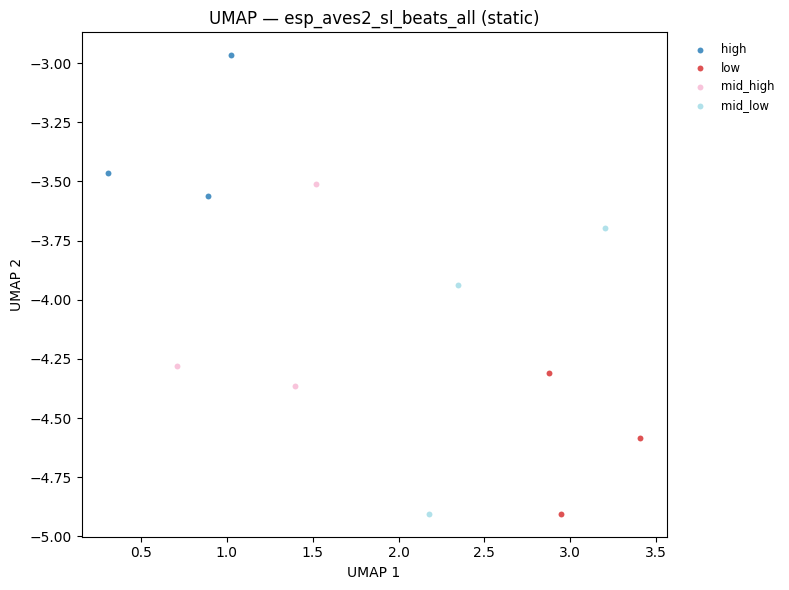

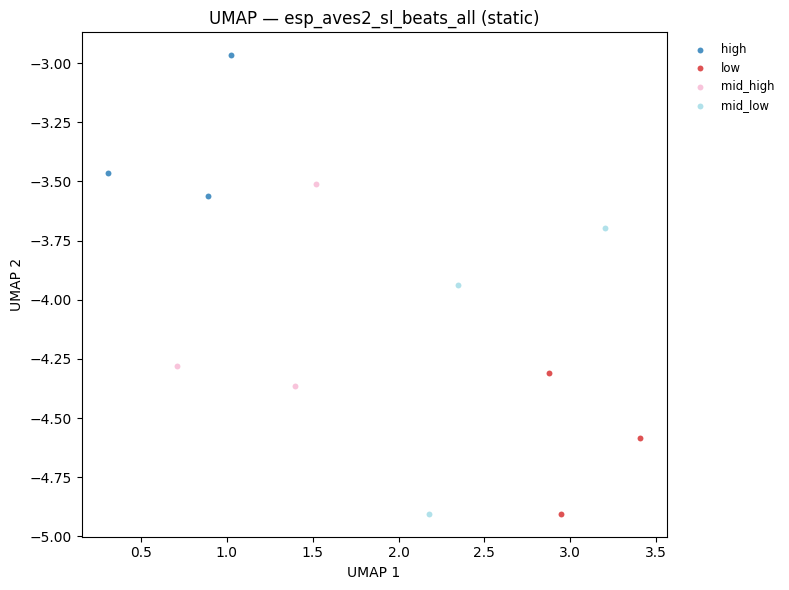

In [10]:
hover = [p.name for p in all_paths]

fig_beats = plot_umap(
    beats_all,
    all_labels,
    title=f"UMAP — {BEATS_MODEL}",
    hover_text=hover,
)
fig_beats.show()
display(plot_umap_static(beats_all, all_labels, title=f"UMAP — {BEATS_MODEL} (static)"))

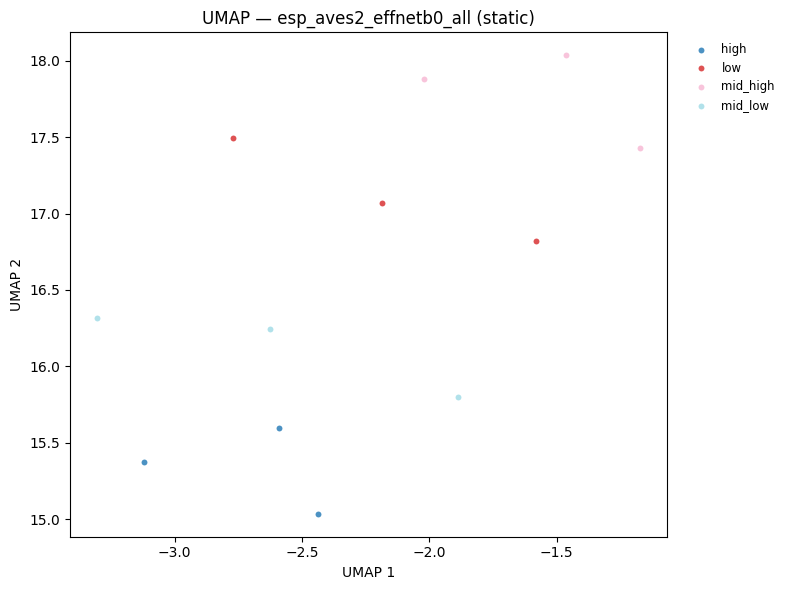

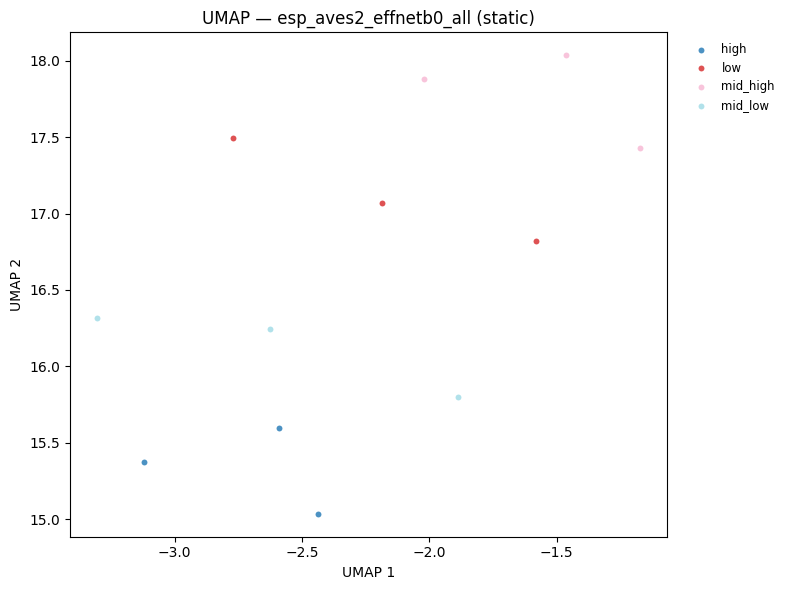

In [11]:
fig_effnet = plot_umap(
    effnet_all,
    all_labels,
    title=f"UMAP — {EFFNET_MODEL}",
    hover_text=hover,
)
fig_effnet.show()
display(plot_umap_static(effnet_all, all_labels, title=f"UMAP — {EFFNET_MODEL} (static)"))

## 8 — Per-window embeddings

So far we have been working with **file-level** embeddings obtained by mean-pooling across all windows. This is the simplest aggregation strategy, but it discards temporal information.

An alternative is to retain all **per-window embeddings** and use them directly:

| Strategy | Shape | Use case |
|---|---|---|
| Mean-pool over windows | `(n_files, emb_dim)` | File classification, retrieval |
| Stack all windows | `(n_files × n_windows, emb_dim)` | Window-level detection, segmentation |
| Temporal sequence | `(n_files, n_windows, emb_dim)` | Sequential modelling (LSTM, attention) |

Below we extract all per-window BEATs embeddings across all 12 files and visualise them in a single UMAP. With 5 windows per 3-second clip, we expect **60 points** (5 × 12). Points from the same file/category should cluster tightly, demonstrating that the windowing does not disrupt the embedding structure.

> **Tip**: With real audio, per-window embeddings enable **temporal analysis** — you can track how the acoustic content of a recording changes over time by examining the trajectory of embeddings in the UMAP space.

Loading esp_aves2_sl_beats_all for window-level analysis...


Total windows: 72  |  embedding dim: 768


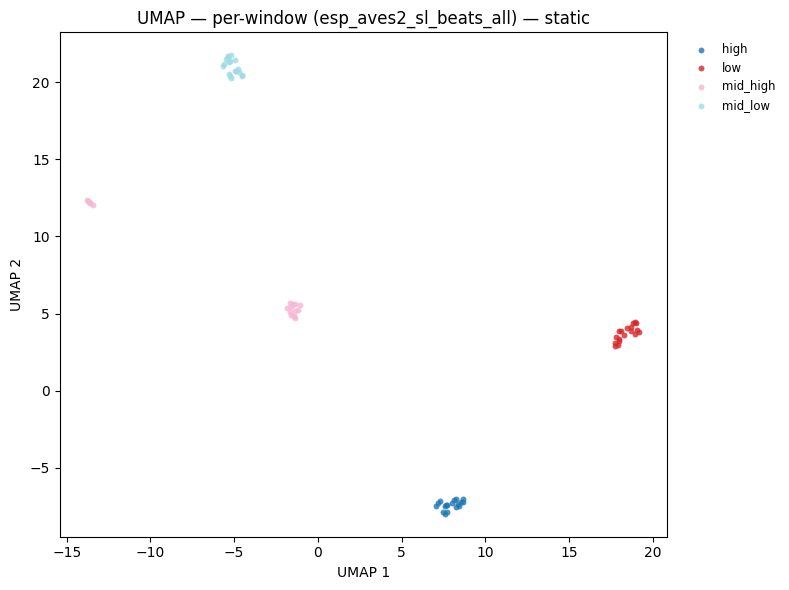

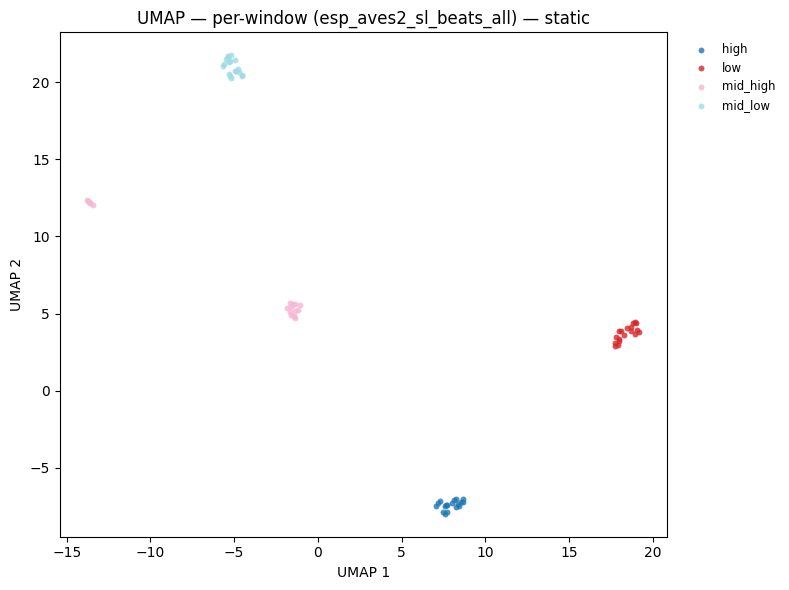

In [12]:
# Reload window-level embeddings for all files
print(f"Loading {BEATS_MODEL} for window-level analysis...")
beats_model_w = load_model(BEATS_MODEL, return_features_only=True, device=DEVICE)
beats_model_w.eval()

window_embs = []
window_labels = []
for p, lbl in zip(all_paths, all_labels, strict=False):
    we = embed_file(p, beats_model_w)  # (n_windows, 768)
    window_embs.append(we.numpy())
    window_labels.extend([lbl] * len(we))
del beats_model_w

window_embs_np = np.concatenate(window_embs, axis=0)  # (total_windows, 768)
print(f"Total windows: {len(window_embs_np)}  |  embedding dim: {window_embs_np.shape[1]}")

fig_win = plot_umap(
    window_embs_np,
    window_labels,
    title=f"UMAP — per-window embeddings ({BEATS_MODEL})<br>"
    f"<sup>{len(window_embs_np)} windows from {len(all_paths)} files</sup>",
)
fig_win.show()
display(
    plot_umap_static(
        window_embs_np,
        window_labels,
        title=f"UMAP — per-window ({BEATS_MODEL}) — static",
    )
)

## 9 — Saving and loading embeddings

Embeddings are the most compute-intensive artifact in the pipeline — model inference dominates runtime. Once extracted, save them to disk so downstream experiments can iterate quickly without re-running the GPU.

Two common formats:
- **`.npy`** (NumPy): simple, portable, fast I/O — ideal for fixed-length arrays
- **`.pt`** (PyTorch): preserves tensor metadata (dtype, device) — preferred when the embeddings will be fed directly into a PyTorch training loop

The `embed_audio.py` script uses `.pt` by default (one file per audio clip per model). Here we use `.npy` for the aggregated arrays since they are already plain NumPy.

In [13]:
# Save window-level embeddings
win_path = EMBED_DIR / "beats_windows.npy"
np.save(win_path, window_embs_np)
print(f"Saved {window_embs_np.shape} array to {win_path}  ({win_path.stat().st_size / 1024:.1f} KB)")

# Reload and verify
loaded = np.load(win_path)
assert np.allclose(loaded, window_embs_np)
print("Reloaded successfully \u2014 arrays match \u2713")

Saved (72, 768) array to /home/marius_miron_earthspecies_org/code/avex-examples/examples/02_embed_audio/demo_embeddings/beats_windows.npy  (216.1 KB)
Reloaded successfully — arrays match ✓


## Summary

This notebook walked through the full batch audio embedding extraction pipeline implemented in `embed_audio.py`:

**Key takeaways**

1. **Windowing is essential** — audio recordings are rarely the exact length a neural model expects. Overlapping windows (`hop < window`) prevent edge-boundary artefacts and provide redundant coverage of acoustic events.

2. **Two complementary models** — BEATs (Transformer) and EfficientNet-B0 (CNN) capture different aspects of the audio signal. BEATs encodes long-range temporal context through self-attention; EfficientNet captures local spectrotemporal texture through multi-scale convolutions. Combining both is common in ensemble systems.

3. **Pooling strategy matters** — mean-pooling over windows is a convenient starting point, but per-window embeddings unlock temporal analysis and are required for segment-level tasks like call onset detection or behaviour segmentation.

4. **Cache your embeddings** — inference is the bottleneck. Save `.npy` or `.pt` files after the first run and load them directly for all subsequent experiments.

**What's next?**

These embeddings are the foundation for every downstream analysis in this repository:

| Example | What it adds |
|---|---|
| `03_beats_layers` | Probe each BEATs transformer layer to find which layer is most informative for your task |
| `04_linear_probe` | Fit a linear classifier on top of frozen embeddings to measure separability |
| `05_knn_retrieval` | Nearest-neighbour audio retrieval using cosine similarity in embedding space |
| `06_cluster` | Unsupervised clustering (k-means, HDBSCAN) for discovering call types |
| `07_finetune` | End-to-end fine-tuning of the backbone on a labelled dataset |

To use your own data, change `AUDIO_DIR` to a folder containing `.wav` or `.flac` files and re-run from Section 5 onwards.